In [1]:
import pickle
import os

from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
load_dotenv()

True

In [72]:
data_folder = os.getenv("DATA_FOLDER")
pond_name = "grass"
pond_count_file = os.path.join(data_folder, "count-data","voronoi-counts", f"voronoi-counts-pond-{pond_name}.npy")
pond_count_times_file = os.path.join(data_folder, "count-data","date-times", f"date-times-pond-{pond_name}.npy")

pond_counts = np.load(pond_count_file)
pond_count_times = np.load(pond_count_times_file, allow_pickle=True)

tlc_counts_file = os.path.join(data_folder, "movement-data.pkl")

with open(tlc_counts_file, "rb") as f:
    tlc_counts =pickle.load(f)

for camera_name, data in tlc_counts.items():
    times = []
    clip_length = []
    for file in data['tracks_files']:
        start_time = file.split('/')[-1].split('_')[2]
        year, month, day = file.split('/')[-2].split('-')
        start_datetime = datetime.datetime(int(year), int(month), int(day), int(start_time[:2]), int(start_time[2:4]), int(start_time[4:6]))
        end_time = file.split('/')[-1].split('_')[3]
        end_datetime = datetime.datetime(int(year), int(month), int(day), int(end_time[:2]), int(end_time[2:4]), int(end_time[4:6])) 
        times.append(start_datetime)
        clip_length.append((end_datetime - start_datetime))
    data['clip_start_time'] = times
    data['clip_length'] = clip_length

    # net change in fish in each clip
    data['net_change'] = data['counts_up'] - data['counts_down']
    data['cumulative_count'] = np.cumsum(data['net_change'])

In [73]:
pond_count_times = [dt - datetime.timedelta(days=1) for dt in pond_count_times]

Text(0.5, 0, 'Date in August')

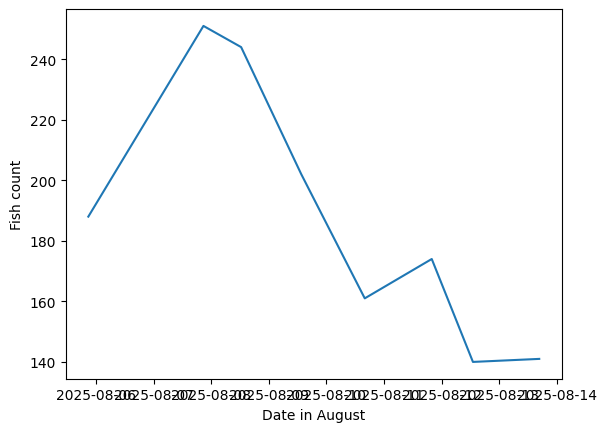

In [74]:
survey_dates = [6, 8, 9, 10, 11, 12, 13, 14]
dates = np.array(survey_dates) - 1

# plt.plot(dates, pond_counts)
# plt.scatter(dates, pond_counts)

plt.plot(pond_count_times, pond_counts)

# plt.scatter(human_dates, human_counts, marker="*")
plt.ylabel("Fish count")
plt.xlabel("Date in August")


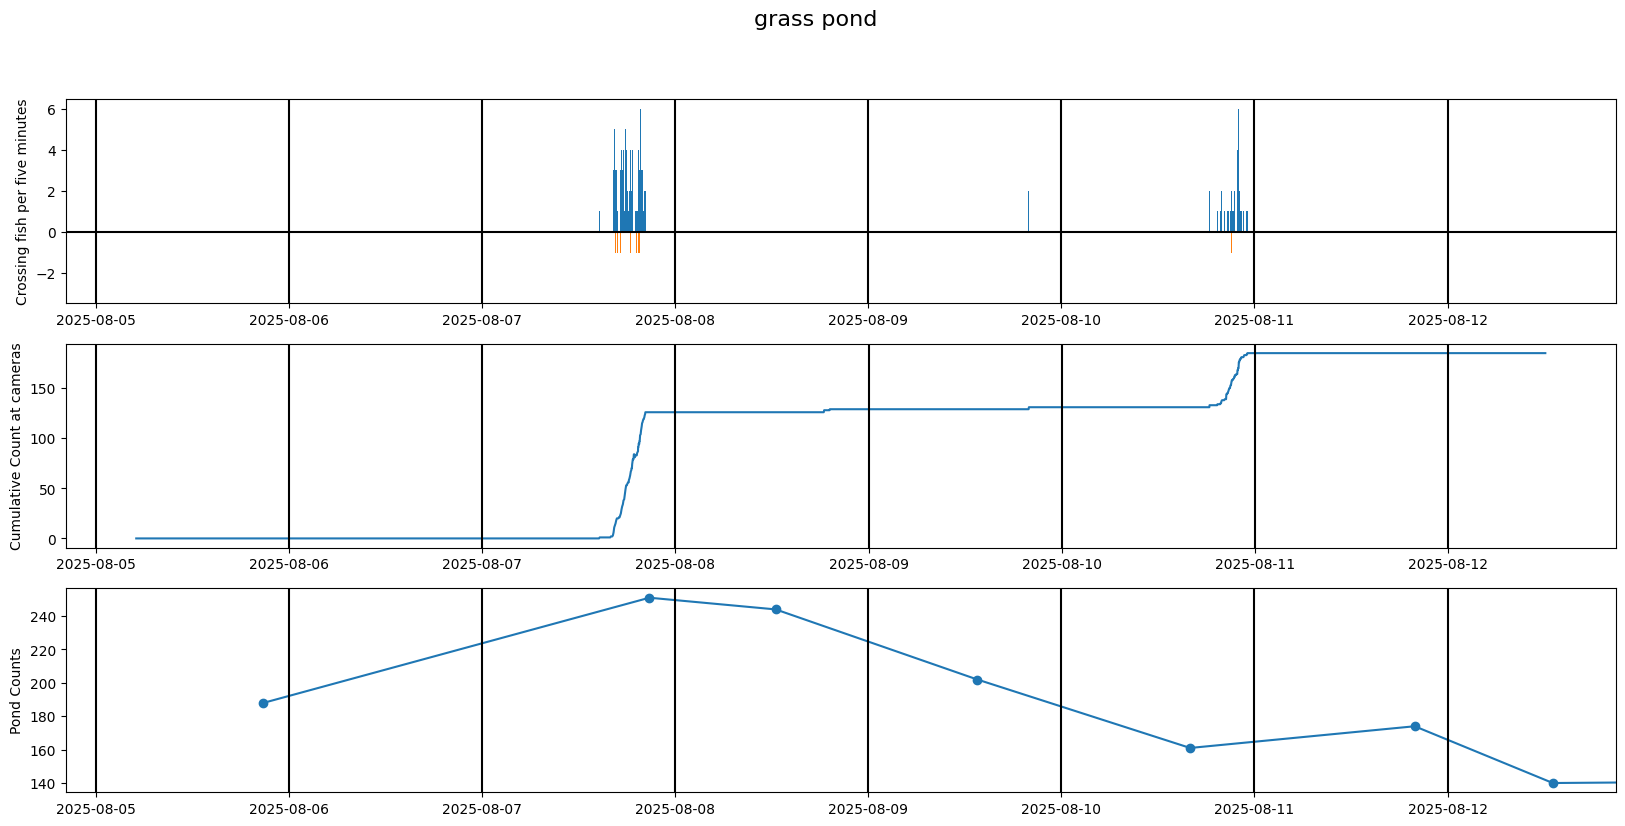

In [75]:
first_date = 5



for camera_name, data in tlc_counts.items():
    if pond_name in camera_name:
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 9))
        first_ind = np.argmax(data['dates']==first_date)
        counts = data['counts_up'][first_ind:]
        counts_down = data['counts_down'][first_ind:]
    
        bar_width = data['clip_length'][first_ind:]
        bar_width = datetime.timedelta(hours=5/60)   
        ax1.bar(data['clip_start_time'][first_ind:], counts, width=bar_width, align='edge', label=camera_name)
        ax1.bar(data['clip_start_time'][first_ind:], -counts_down, width=bar_width, align='edge', label=camera_name)
        ax1.axhline(y=0, c="0.0")
        ax1.set_ylabel(f"Crossing fish per five minutes")

        ax2.plot(data['clip_start_time'][first_ind:], data['cumulative_count'][first_ind:], label=f"{camera_name} - Cumulative Count")
        ax2.set_ylabel(f"Cumulative Count at cameras")

        ax3.plot(pond_count_times, pond_counts)
        ax3.scatter(pond_count_times, pond_counts)
        ax3.set_xlim(ax1.get_xlim())
        ax3.set_ylabel(f"Pond Counts")
        
        for date in np.unique(data['dates'][first_ind:]):
            new_day = datetime.datetime(int(2025), int(8), int(date), int(0), int(0), int(0))
            ax1.axvline(x=new_day, c="0.0")
            ax2.axvline(x=new_day, c="0.0")
            ax3.axvline(x=new_day, c="0.0")


        fig.suptitle(f'{pond_name} pond', fontsize=16)

        # save the plot
        plots_folder = os.path.join(data_folder, 'plots')
        os.makedirs(plots_folder, exist_ok=True)
        save_file = os.path.join(plots_folder, f'{pond_name}_analysis.png')
        plt.savefig(save_file, dpi=300, bbox_inches='tight')


        

In [28]:
bar_width

[datetime.timedelta(seconds=120),
 datetime.timedelta(seconds=302),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=300),
 datetime.timedelta(seconds=299),
 datetime.timedelta(seconds=299),
 datetime.time

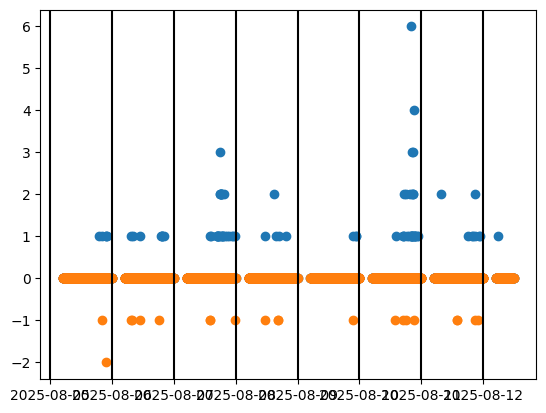

In [20]:
first_date = 5

for camera_name, data in tlc_counts.items():
    if pond_name in camera_name:
        plt.figure()
        first_ind = np.argmax(data['dates']==first_date)
        counts = data['counts_up'][first_ind:]
        counts_down = data['counts_down'][first_ind:]

        plt.scatter(data['clip_start_time'][first_ind:], counts, label=camera_name)
        plt.scatter(data['clip_start_time'][first_ind:], -counts_down, label=camera_name)

        for date in np.unique(data['dates'][first_ind:]):
            new_day = datetime.datetime(int(2025), int(8), int(date), int(0), int(0), int(0))
            plt.axvline(x=new_day, c="0.0")

        # plt.legend()

In [12]:
import datetime

In [24]:
file

'/home/bkoger/project/uwyo-0003/salmon-tlc/processing/predictions_05-27-2026-14-13-10/cam09-trail_outflow/2025-08-12/RecM0A_DST20250812_135952_140221_0_531E8300000000_27D57FD-tracks-class-3.pkl'